# Does stimulation move activity along the natural disengagement axis?

**Hypothesis.** Train a population coding direction (CD) to separate *engaged*
from *no-response* (and *reward* from *no-reward*) trials using **unstimulated**
data, then project **stimulation** trials onto that axis. If stimulation pushes
the population toward the natural *no-response* (disengaged) state — and the
per-trial magnitude predicts behaviour — that supports a causal role for the
stimulated region in disengagement.

**Design.**
1. Select units: all default-QC units, optionally restricted to **opto-tagged**
   units and/or specific **probes** (we have no anatomy yet, so probe/tag is the
   proxy for region).
2. Build the CD on **unstimulated** trials only, for two contrasts:
   - `response`: engaged (`animal_response != 2`) vs no-response (`== 2`)
   - `reward`:   rewarded vs unrewarded (responded, no reward)
3. Enumerate the **stimulation conditions** present in the session.
4. Project a chosen condition's trials onto the unstim axis and test whether
   they shift toward the disengaged pole; quantify with a **disengagement index**
   (0 = engaged pole, 1 = disengaged pole) and ask whether the per-trial
   projection predicts no-response behaviour.

The heavy lifting lives in `stim_axis_projection.py`; this notebook just wires
it together so it runs standalone on the capsule.

In [76]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [77]:
# =============================================================================
# 2. CONFIG
# =============================================================================
import re
from pathlib import Path

# --- Session identifiers -----------------------------------------------------
session_date = '863973_2026-08-25_14-18-29'
ephys_session = None   # None -> auto-discover from the PSTH Zarr in step 3

# --- Paths -------------------------------------------------------------------
PSTH_DIR = Path("/root/capsule/scratch/psth_results")
RESULTS_DIR = Path("/root/capsule/scratch/behavior_summary")

# --- Unit selection (same combinable filters as the PSTH notebooks) ----------
#   USE_TAGGED : if True, keep only opto-tagged units (from the metrics CSV below)
#   PROBES     : if a non-empty list, keep only units on those NWB 'device_name'
#                probes (e.g. ["ProbeA"]); None/[] = all probes.
# If BOTH are set, a unit must satisfy BOTH (tagged AND on a listed probe).
USE_TAGGED = False     # True -> restrict to opto-tagged units
PROBES = ["ProbeA-1","ProbeA-2","ProbeA-3","ProbeA-4"]          # e.g. ["ProbeA"] or ["ProbeA", "ProbeB"]; None/[] -> all probes
#PROBES = ["ProbeC-1","ProbeC-2","ProbeC-3","ProbeC-4"] 


# Opto-tagging source + condition (only used when USE_TAGGED is True).
metrics_csv_path = Path(f"/root/capsule/scratch/opto_tagging/metrics_{session_date}.csv")
#   (target_power, location_tag, laser_name, cycle_duration, frequency, pulse_duration)
target_cond = (5.0, 1.0, "Laser_1", 1.0, 10.0, 0.05)
SELECT_PULSE_INDEX = -1   # -1 = pooled over all pulses in the train

# --- Coding-direction parameters ---------------------------------------------
ALIGN_TO = "go_cue"       # alignment event for the CD
FIT_WINDOW = (0.0, 0.5)   # window (s) used to FIT the CD axis
PROJ_WINDOW = (-4, 6) # window (s) for the time-resolved projection trace (None = full)
AXES_TO_BUILD = ["response", "reward"]

# Output folder encodes the unit selection so runs don't overwrite each other.
_tag_part = "tagged" if USE_TAGGED else "allqc"
_probe_part = "all_probes" if not PROBES else "probe_" + "_".join(
    re.sub(r"[^0-9A-Za-z._-]", "", str(p)) for p in PROBES
)
OUTDIR = Path(f"/root/capsule/scratch/stim_cd_projection/{session_date}/{_tag_part}__{_probe_part}")

print(f"Use tagged : {USE_TAGGED}")
print(f"Probes     : {'all' if not PROBES else PROBES}")
print(f"Axes       : {AXES_TO_BUILD}")
print(f"Output dir : {OUTDIR}")

Use tagged : False
Probes     : ['ProbeA-1', 'ProbeA-2', 'ProbeA-3', 'ProbeA-4']
Axes       : ['response', 'reward']
Output dir : /root/capsule/scratch/stim_cd_projection/863973_2026-08-25_14-18-29/allqc__probe_ProbeA-1_ProbeA-2_ProbeA-3_ProbeA-4


In [78]:
# =============================================================================
# 3. LOAD SESSION RESOURCES (Zarr PSTH, behavior summary, NWB, trials)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from general_utils import smart_read_csv
from behavior_utils import find_trials
from nwb_utils import NWBUtils
from create_psth import load_zarr

# Auto-discover the full sorted session name from the PSTH Zarr if not set.
if ephys_session is None:
    cands = sorted(PSTH_DIR.glob(f"ecephys_{session_date}_sorted*_0.2s.zarr"))
    if not cands:
        raise FileNotFoundError(
            f"No PSTH Zarr matching ecephys_{session_date}_sorted*_0.2s.zarr in {PSTH_DIR}"
        )
    ephys_session = cands[0].name[: -len("_0.2s.zarr")]
print(f"ephys_session: {ephys_session}")

zarr_path = PSTH_DIR / f"{ephys_session}_0.2s.zarr"
beh_csv = RESULTS_DIR / f"behavior_summary-{ephys_session}.csv"
assert zarr_path.exists(), f"Zarr not found: {zarr_path}"
assert beh_csv.exists(), f"Behavior CSV not found: {beh_csv}"

nwb, _ = NWBUtils.combine_nwb(session_name=ephys_session)
psth = load_zarr(str(zarr_path))
beh = smart_read_csv(str(beh_csv))

# Laser-on trials -> the stimulation set; everything else is 'unstimulated'.
if "laser_on_trial" in nwb.trials.colnames:
    laser_on = np.asarray(nwb.trials["laser_on_trial"][:])
    opto_trial_ids = np.where(laser_on == 1)[0].astype(np.int64)
else:
    opto_trial_ids = np.array([], dtype=np.int64)
print(f"laser-on (stimulation) trials: {len(opto_trial_ids)}")
print(f"response trials: {len(find_trials(nwb, 'response'))}, "
      f"no-response: {len(find_trials(nwb, 'no_response'))}")

OUTDIR.mkdir(parents=True, exist_ok=True)

ephys_session: ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54
Found ephys NWB: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54/nwb/ecephys_863973_2026-08-25_14-18-29_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54/nwb/ecephys_863973_2026-08-25_14-18-29_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/863973_2026-08-25_14-18-29.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/863973_2026-08-25_14-18-29.nwb
Successfully appended units table to behavior NWB.
laser-on (stimulation) trials: 86
response trials: 420, no-response: 121


In [79]:
# =============================================================================
# 4. SELECT UNITS  (default QC, optionally AND opto-tagged, optionally AND probe)
# =============================================================================
from ephys_behavior import get_units_passed_default_qc

# Probe (device) name per unit, straight from the NWB units table. The row index
# here matches the PSTH 'unit_index' coordinate.
device_names = np.asarray(nwb.units["device_name"][:]).astype(str)
avail_probes = sorted(set(device_names))
print(f"Probes in this session: {avail_probes}")

# Base set: units passing the automated default QC (presence/isi/amplitude + not 'noise').
qc_units = np.asarray(get_units_passed_default_qc(nwb), dtype=np.int64)
sel = set(int(u) for u in qc_units)
print(f"QC-passed units: {len(sel)}")

# --- Filter 1 (optional): opto-tagged units ----------------------------------
if USE_TAGGED:
    import pandas as pd
    from ast import literal_eval
    from optical_tagging import select_tagged_units

    metrics_df = pd.read_csv(metrics_csv_path)
    tagged_df = select_tagged_units(
        metrics_df, alpha=0.05, effect_ratio=2.0, min_abs_increase=0.0,
        min_reliability=0.2, max_latency=0.006, max_jitter=0.003, correction="fdr_bh",
    )

    def _as_tuple(c):
        if isinstance(c, str):
            c = re.sub(r"np\.\w+\(([^()]*)\)", r"\1", c)
            try:
                c = literal_eval(c)
            except (ValueError, SyntaxError):
                return None
        return tuple(c) if isinstance(c, (tuple, list)) else None

    _match_idx = [i for i in range(6) if i != 2]  # match all fields except laser_name

    def _matches(c):
        c = _as_tuple(c)
        return c is not None and len(c) == 6 and all(c[i] == target_cond[i] for i in _match_idx)

    cond_mask = tagged_df["condition"].apply(_matches)
    pulse_mask = tagged_df["pulse_index"] == SELECT_PULSE_INDEX
    sigrows = tagged_df[cond_mask & pulse_mask & (tagged_df["tagged"] == True)]
    tagged_units = set(int(u) for u in sigrows["unit_id"].unique())
    print(f"Opto-tagged units ({target_cond}, pulse={SELECT_PULSE_INDEX}): {len(tagged_units)}")
    sel &= tagged_units

# --- Filter 2 (optional): specific probes ------------------------------------
if PROBES:
    want = [str(p) for p in PROBES]
    missing = [p for p in want if p not in avail_probes]
    if missing:
        print(f"WARNING: requested probes not present: {missing}")
    on_probe = set(int(u) for u in np.where(np.isin(device_names, want))[0])
    sel &= on_probe

unit_ids = sorted(sel)

# Keep only units that actually exist in the PSTH store.
try:
    psth_units = {int(u) for u in np.asarray(psth.coords["unit_index"].values)}
except Exception:
    psth_units = None
if psth_units is not None:
    unit_ids = [u for u in unit_ids if u in psth_units]

sel_probes = device_names[unit_ids] if len(unit_ids) else np.array([], dtype=str)
counts = {p: int(np.sum(sel_probes == p)) for p in sorted(set(sel_probes))}
print(f"Filters -> tagged={USE_TAGGED}, probes={'all' if not PROBES else PROBES}")
print(f"Selected units ({len(unit_ids)}): {unit_ids}")
print(f"Units per probe: {counts}")
if len(unit_ids) < 3:
    raise ValueError(
        "Fewer than 3 units after selection — a population CD needs more units. "
        "Loosen the filters or check target_cond / PROBES / metrics_csv_path."
    )

Probes in this session: [np.str_('ProbeA-1'), np.str_('ProbeA-2'), np.str_('ProbeA-3'), np.str_('ProbeA-4'), np.str_('ProbeB-1'), np.str_('ProbeB-2'), np.str_('ProbeB-3'), np.str_('ProbeB-4'), np.str_('ProbeC-1'), np.str_('ProbeC-2'), np.str_('ProbeC-3'), np.str_('ProbeC-4')]
Number of units passing QC: 2204
QC-passed units: 2204
Filters -> tagged=False, probes=['ProbeA-1', 'ProbeA-2', 'ProbeA-3', 'ProbeA-4']
Selected units (579): [5, 7, 9, 15, 18, 19, 22, 23, 26, 27, 28, 29, 32, 34, 37, 38, 40, 41, 42, 43, 46, 48, 49, 50, 51, 52, 53, 55, 58, 59, 60, 61, 65, 66, 72, 76, 78, 82, 87, 89, 90, 91, 94, 99, 100, 101, 102, 104, 105, 106, 107, 108, 109, 111, 115, 116, 117, 118, 120, 121, 122, 124, 125, 126, 128, 129, 131, 132, 133, 134, 135, 136, 139, 142, 145, 147, 149, 151, 152, 153, 154, 155, 156, 157, 158, 160, 161, 163, 165, 166, 167, 168, 170, 172, 174, 175, 176, 179, 182, 185, 187, 195, 196, 198, 201, 206, 208, 210, 212, 214, 215, 217, 219, 220, 222, 224, 225, 229, 231, 232, 234, 235, 2

## 5. Stimulation conditions

Enumerate the distinct stimulation conditions present in the session (grouped by
laser timing/duration parameters). Each row lists the absolute `trial_ids` for
that condition, so we can later project exactly those trials onto the unstim CD.
Set `STIM_GROUP_COLS` if you want to group by different laser parameters.

In [80]:
# =============================================================================
# 5. ENUMERATE STIMULATION CONDITIONS
# =============================================================================
from ephys_while_stimulation import summarize_laser_conditions

# Laser parameters that define a 'condition'. Adjust to taste, e.g. add
# 'laser_location', 'laser_1_power', 'laser_frequency'.
STIM_GROUP_COLS = (
    "laser_start", "laser_start_offset", "laser_end", "laser_end_offset", "laser_duration",
)

stim_summary = summarize_laser_conditions(nwb, group_cols=STIM_GROUP_COLS)
print(f"{len(stim_summary)} stimulation condition(s):")
display(stim_summary.drop(columns=["trial_ids"]))

# Map: condition index -> np.ndarray of absolute trial ids.
stim_conditions = {
    i: np.asarray(row["trial_ids"], dtype=np.int64)
    for i, row in stim_summary.iterrows()
}

3 stimulation condition(s):


,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_duration,n_trials
0,Go cue,0.3,NA,0.00,3.0,47
1,Trial start,0.0,Go cue,-0.85,50.0,34
2,Trial start,0.0,Go cue,0.00,50.0,5


## 6. Build coding directions on unstimulated trials

For each contrast in `AXES_TO_BUILD`, fit a CD using **only non-laser** trials
(class A = engaged/reward pole, class B = disengaged/no-reward pole). The axis is
cross-validated (balanced two-fold), and the fitted model additionally projects
*every* trial in the session — including the stimulation trials — onto the axis.
`d'` and `AUC` report how well the unstim axis separates its own held-out trials.

In [81]:
# =============================================================================
# 6. BUILD CD AXES (unstimulated trials only)
# =============================================================================
from stim_axis_projection import build_axis

axes = {}
for axis_name in AXES_TO_BUILD:
    res = build_axis(
        psth, nwb, unit_ids, axis_name,
        align=ALIGN_TO, fit_window=FIT_WINDOW, proj_window=PROJ_WINDOW,
        exclude_trial_ids=opto_trial_ids,   # fit on non-laser trials only
    )
    axes[axis_name] = res
    print(f"[{axis_name}] fit on A={res.ids_a.size} vs B={res.ids_b.size} unstim trials | "
          f"d'={res.dprime:.2f}, AUC={res.auc:.2f}")

[response] fit on A=363 vs B=92 unstim trials | d'=2.06, AUC=0.57
[reward] fit on A=190 vs B=173 unstim trials | d'=0.27, AUC=0.51


## 7. Project one stimulation condition onto the axes

Pick a stimulation condition (`STIM_CONDITION`, an index from section 5) and an
axis (`PROJECT_AXIS`). We project that condition's trials onto the unstim CD and
compare against the unstim engaged/disengaged reference distributions.

- **Strip plot** — fit-window projections for unstim-A, unstim-B and stim trials.
- **Time-resolved** — mean ± SEM projection trace for the three groups.
- **Disengagement index** — 0 at the engaged pole, 1 at the disengaged pole; a
  positive shift with small p means stimulation moves activity toward no-response.
- **Behaviour AUC** — whether the per-trial projection predicts no-response on the
  stimulated trials (the "magnitude predicts behaviour" test).

Axis            : response  (A=engaged (response), B=disengaged (no-response))
Stim trials     : 34  (18 no-response)
Disengagement   : 0.131 ± 0.089  (0 = engaged pole, 1 = disengaged pole)
Shift toward B  : Mann-Whitney p = 0.0738
Behaviour AUC   : 0.844  (projection -> no-response)


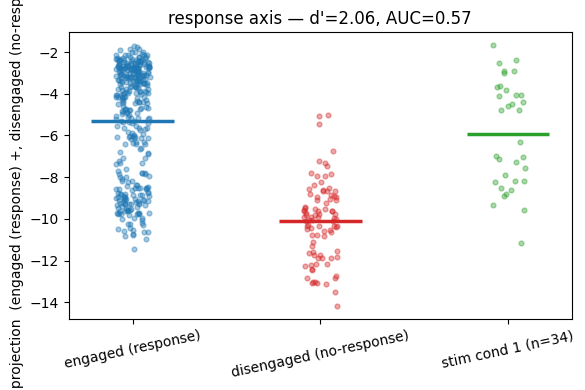

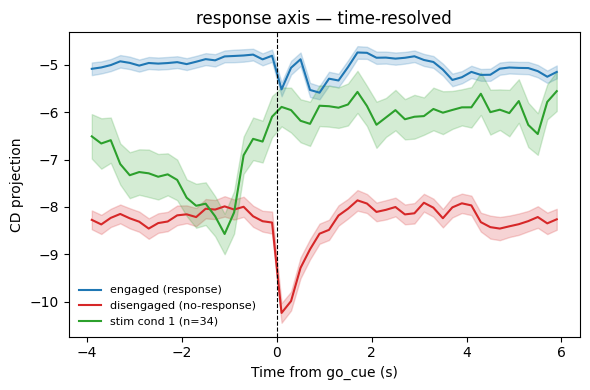

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'response axis — time-resolved'}, xlabel='Time from go_cue (s)', ylabel='CD projection'>)

In [82]:
# =============================================================================
# 7. PROJECT A SELECTED STIMULATION CONDITION
# =============================================================================
from stim_axis_projection import condition_shift, plot_axis_distributions, plot_axis_traces

STIM_CONDITION = 1            # index into stim_conditions (see section 5 table)
PROJECT_AXIS = "response"     # which axis in AXES_TO_BUILD to project onto. response or reward

res = axes[PROJECT_AXIS]
cond_ids = stim_conditions[STIM_CONDITION]
stim_label = f"stim cond {STIM_CONDITION} (n={cond_ids.size})"
tag = f"{PROJECT_AXIS}_cond{STIM_CONDITION}"

stats = condition_shift(res, cond_ids, nwb)
print(f"Axis            : {PROJECT_AXIS}  (A={res.axis['label_a']}, B={res.axis['label_b']})")
print(f"Stim trials     : {stats['n_stim']}  ({stats['n_no_response']} no-response)")
print(f"Disengagement   : {stats['mean_di']:.3f} ± {stats['sem_di']:.3f}  "
      f"(0 = engaged pole, 1 = disengaged pole)")
print(f"Shift toward B  : Mann-Whitney p = {stats['p_toward_disengaged']:.3g}")
print(f"Behaviour AUC   : {stats['behavior_auc']:.3f}  (projection -> no-response)")

plot_axis_distributions(
    res, cond_ids, stim_label=stim_label, show=True,
    save_path=str(OUTDIR / f"projection_strip_{tag}.png"),
)
plot_axis_traces(
    res, cond_ids, stim_label=stim_label, show=True,
    save_path=str(OUTDIR / f"projection_trace_{tag}.png"),
)

## 8. Summary across all conditions and axes

Loop over every stimulation condition and every built axis, collecting the
disengagement index, the one-sided shift p-value, and the behaviour-prediction
AUC into a single table. Rows with a positive `mean_di`, small
`p_toward_disengaged`, and `behavior_auc > 0.5` are the compelling cases where
stimulation pushes the population toward the natural no-response state and that
shift tracks behaviour.

In [83]:
# =============================================================================
# 8. SUMMARY TABLE: all conditions x all axes
# =============================================================================
import pandas as pd
from stim_axis_projection import condition_shift

rows = []
for axis_name, res in axes.items():
    for ci, cond_ids in stim_conditions.items():
        s = condition_shift(res, cond_ids, nwb)
        rows.append(dict(
            axis=axis_name,
            condition=ci,
            n_stim=s["n_stim"],
            n_no_response=s["n_no_response"],
            mean_disengagement=round(s["mean_di"], 3),
            sem_disengagement=round(s["sem_di"], 3),
            p_toward_disengaged=s["p_toward_disengaged"],
            behavior_auc=round(s["behavior_auc"], 3),
            axis_dprime=round(res.dprime, 2),
            axis_auc=round(res.auc, 2),
        ))

summary = pd.DataFrame(rows).sort_values(["axis", "condition"]).reset_index(drop=True)
summary_path = OUTDIR / "stim_cd_projection_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved summary -> {summary_path}")
display(summary)

Saved summary -> /root/capsule/scratch/stim_cd_projection/863973_2026-08-25_14-18-29/allqc__probe_ProbeA-1_ProbeA-2_ProbeA-3_ProbeA-4/stim_cd_projection_summary.csv


,axis,condition,n_stim,n_no_response,mean_disengagement,sem_disengagement,p_toward_disengaged,behavior_auc,axis_dprime,axis_auc
0,response,0,47,10,0.368,0.098,8.961406e-05,0.903,2.06,0.57
1,response,1,34,18,0.131,0.089,7.379306e-02,0.844,2.06,0.57
2,response,2,5,1,-0.544,0.038,9.948839e-01,1.000,2.06,0.57
3,reward,0,47,10,5.264,0.676,3.710862e-11,0.895,0.27,0.51
4,reward,1,34,18,3.233,0.616,5.121625e-06,0.840,0.27,0.51
5,reward,2,5,1,-3.510,0.366,9.932647e-01,0.500,0.27,0.51


## 9. Parameter sweep → one combined summary figure

Sweep every combination and collapse the results into a **single** figure:

- **CD fit windows**: pre go-cue `(-0.5, 0)`, early `(0, 0.1)`, late `(0.3, 2)`
- **Unit selections**: all tagged units (`tagged=True`, all probes), and
  `tagged=False` on each probe group — `ProbeA-[1-4]`, `ProbeB-[1-4]`, `ProbeC-[1-4]`
- **Stimulation conditions**: `0` and `1` (indices from section 5)
- **Axes**: `response` and `reward`

The summary figure is a grid (rows = axis, columns = fit window). In each panel
the x-axis is the unit selection and the grouped bars are the two stimulation
conditions, showing the mean ± SEM **disengagement index** (0 = engaged pole,
1 = disengaged pole; dashed guides). Values near/above 1 mean stimulation drives
the population toward the natural no-response state. The full tidy table (incl.
`p_toward_disengaged` and `behavior_auc`) is saved to CSV alongside the figure.

In [84]:
# =============================================================================
# 9a. RUN THE SWEEP (units x fit-window x axis x stim-condition)
# =============================================================================
import pandas as pd
from stim_axis_projection import select_units, build_axis, condition_shift

# --- Sweep grid --------------------------------------------------------------
UNIT_SELECTIONS = [
    ("tagged-all", dict(use_tagged=True,  probes=None)),
    ("ProbeA",     dict(use_tagged=False, probes=["ProbeA-1", "ProbeA-2", "ProbeA-3", "ProbeA-4"])),
    ("ProbeB",     dict(use_tagged=False, probes=["ProbeB-1", "ProbeB-2", "ProbeB-3", "ProbeB-4"])),
    ("ProbeC",     dict(use_tagged=False, probes=["ProbeC-1", "ProbeC-2", "ProbeC-3", "ProbeC-4"])),
]
FIT_WINDOWS = [
    ("pre (-0.5,0)", (-0.5, 0.0)),
    ("early (0,0.1)", (0.0, 0.1)),
    ("late (0.3,2)", (0.3, 2.0)),
]
SWEEP_AXES = ["response", "reward"]
SWEEP_STIM_CONDITIONS = [0, 1]

# Units depend only on the selection (not on window/axis) -> resolve once each.
units_by_sel = {}
for name, kw in UNIT_SELECTIONS:
    try:
        uids = select_units(
            nwb, psth, metrics_csv_path=metrics_csv_path,
            target_cond=target_cond, pulse_index=SELECT_PULSE_INDEX, **kw,
        )
    except Exception as e:
        print(f"[{name}] unit selection failed: {e}")
        uids = []
    units_by_sel[name] = uids
    print(f"{name:12s}: {len(uids)} units")

rows = []
for sel_name, _ in UNIT_SELECTIONS:
    uids = units_by_sel[sel_name]
    if len(uids) < 3:
        print(f"skip {sel_name}: <3 units")
        continue
    for win_label, win in FIT_WINDOWS:
        for axis_name in SWEEP_AXES:
            try:
                res = build_axis(
                    psth, nwb, uids, axis_name, align=ALIGN_TO,
                    fit_window=win, proj_window=PROJ_WINDOW,
                    exclude_trial_ids=opto_trial_ids,
                )
            except Exception as e:
                print(f"skip {sel_name}/{win_label}/{axis_name}: {e}")
                continue
            for ci in SWEEP_STIM_CONDITIONS:
                if ci not in stim_conditions:
                    continue
                s = condition_shift(res, stim_conditions[ci], nwb)
                rows.append(dict(
                    selection=sel_name, window_label=win_label, axis=axis_name,
                    condition=ci, n_units=len(uids), n_stim=s["n_stim"],
                    mean_di=s["mean_di"], sem_di=s["sem_di"],
                    p_toward_disengaged=s["p_toward_disengaged"],
                    behavior_auc=s["behavior_auc"],
                    axis_dprime=res.dprime, axis_auc=res.auc,
                ))

sweep_df = pd.DataFrame(rows)
sweep_path = OUTDIR / "stim_cd_sweep_summary.csv"
sweep_df.to_csv(sweep_path, index=False)
print(f"Saved sweep table -> {sweep_path}")
display(sweep_df)

Number of units passing QC: 2204
tagged-all  : 122 units
Number of units passing QC: 2204
ProbeA      : 579 units
Number of units passing QC: 2204
ProbeB      : 554 units
Number of units passing QC: 2204
ProbeC      : 1071 units
  [snap] window (0.0, 0.1) spans no PSTH bin (bin width ~0.2s); using nearest bin centered at 0.1s -> (5.25e-15, 0.2)
  [snap] window (0.0, 0.1) spans no PSTH bin (bin width ~0.2s); using nearest bin centered at 0.1s -> (5.25e-15, 0.2)
  [snap] window (0.0, 0.1) spans no PSTH bin (bin width ~0.2s); using nearest bin centered at 0.1s -> (5.25e-15, 0.2)
  [snap] window (0.0, 0.1) spans no PSTH bin (bin width ~0.2s); using nearest bin centered at 0.1s -> (5.25e-15, 0.2)
  [snap] window (0.0, 0.1) spans no PSTH bin (bin width ~0.2s); using nearest bin centered at 0.1s -> (5.25e-15, 0.2)
  [snap] window (0.0, 0.1) spans no PSTH bin (bin width ~0.2s); using nearest bin centered at 0.1s -> (5.25e-15, 0.2)
  [snap] window (0.0, 0.1) spans no PSTH bin (bin width ~0.2s);

,selection,window_label,axis,condition,n_units,n_stim,mean_di,sem_di,p_toward_disengaged,behavior_auc,axis_dprime,axis_auc
0,tagged-all,"pre (-0.5,0)",response,0,122,47,0.307983,0.111966,8.635495e-03,0.924324,2.077965,0.579680
1,tagged-all,"pre (-0.5,0)",response,1,122,34,-0.325177,0.093733,9.970633e-01,0.600694,2.077965,0.579680
2,tagged-all,"pre (-0.5,0)",reward,0,122,47,13.601850,5.281673,1.526073e-01,0.940541,0.013754,0.486097
3,tagged-all,"pre (-0.5,0)",reward,1,122,34,-16.708593,5.000360,8.892587e-01,0.427083,0.013754,0.486097
4,tagged-all,"early (0,0.1)",response,0,122,47,0.270736,0.103063,1.095481e-02,0.940541,2.327122,0.565726
5,tagged-all,"early (0,0.1)",response,1,122,34,0.034815,0.071830,2.207173e-01,0.899306,2.327122,0.565726
6,tagged-all,"early (0,0.1)",reward,0,122,47,-47.669002,11.771181,9.999433e-01,0.083784,-0.017438,0.501308
7,tagged-all,"early (0,0.1)",reward,1,122,34,-33.819477,9.155803,9.990097e-01,0.246528,-0.017438,0.501308
8,tagged-all,"late (0.3,2)",response,0,122,47,0.891656,0.034902,2.606374e-24,0.843243,2.814604,0.565876
9,tagged-all,"late (0.3,2)",response,1,122,34,0.252499,0.078554,1.301511e-03,0.906250,2.814604,0.565876


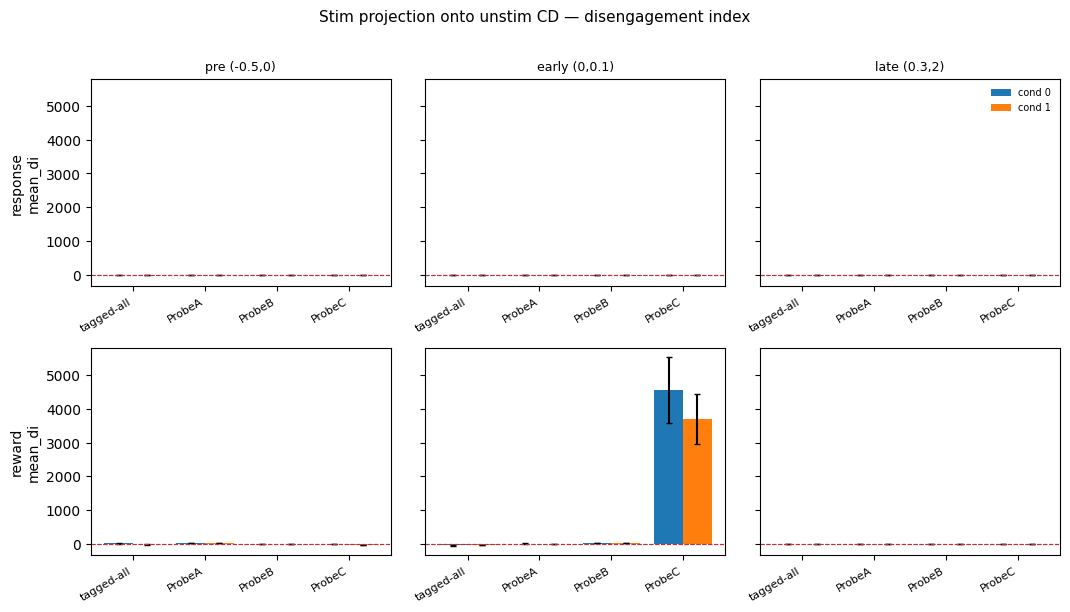

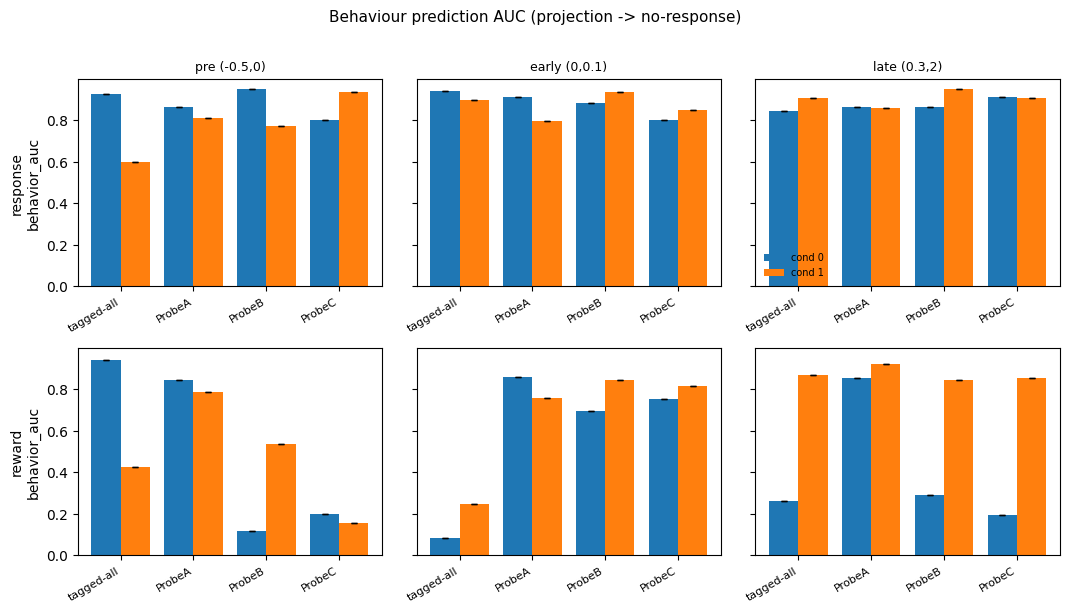

(<Figure size 1080x620 with 6 Axes>,
 array([[<Axes: title={'center': 'pre (-0.5,0)'}, ylabel='response\nbehavior_auc'>,
         <Axes: title={'center': 'early (0,0.1)'}>,
         <Axes: title={'center': 'late (0.3,2)'}>],
        [<Axes: ylabel='reward\nbehavior_auc'>, <Axes: >, <Axes: >]],
       dtype=object))

In [85]:
# =============================================================================
# 9b. SINGLE COMBINED SUMMARY FIGURE
# =============================================================================
from stim_axis_projection import plot_sweep_summary

# Primary readout: disengagement index (0 = engaged pole, 1 = disengaged pole).
plot_sweep_summary(
    sweep_df, metric="mean_di", err="sem_di",
    axis_order=SWEEP_AXES,
    window_order=[w[0] for w in FIT_WINDOWS],
    sel_order=[s[0] for s in UNIT_SELECTIONS],
    cond_order=SWEEP_STIM_CONDITIONS,
    title="Stim projection onto unstim CD — disengagement index",
    save_path=str(OUTDIR / "stim_cd_sweep_disengagement.png"),
    show=True,
)

# Companion readout: does the per-trial projection predict no-response?
plot_sweep_summary(
    sweep_df, metric="behavior_auc", err=None,
    axis_order=SWEEP_AXES,
    window_order=[w[0] for w in FIT_WINDOWS],
    sel_order=[s[0] for s in UNIT_SELECTIONS],
    cond_order=SWEEP_STIM_CONDITIONS,
    title="Behaviour prediction AUC (projection -> no-response)",
    save_path=str(OUTDIR / "stim_cd_sweep_behavior_auc.png"),
    show=True,
)

## 9c. Swept detailed figures

For every swept combination this produces the *detailed* view (time-resolved
projection traces for engaged / disengaged / stim), laid out as a grid of
**unit-selection (rows) × fit-window (columns)**, one combined figure per
`(axis, stim-condition)`. It also saves the per-combo strip + trace plots to
disk so you can inspect any single cell of the grid at full size.


In [86]:
# =============================================================================
# 9c. SWEPT DETAILED FIGURES (trace grid + per-combo strip / trace)
# =============================================================================
from stim_axis_projection import (
    plot_trace_grid, plot_axis_distributions, plot_axis_traces,
)

DETAIL_DIR = OUTDIR / "detail"
DETAIL_DIR.mkdir(parents=True, exist_ok=True)

# selections/windows actually present in the cache (keeps layout aligned)
_sel_order = [s for s, _ in UNIT_SELECTIONS
              if any(k[0] == s for k in axis_cache)]
_win_order = [w for w, _ in FIT_WINDOWS
              if any(k[1] == w for k in axis_cache)]

# ---- combined grid: one figure per (axis, stim condition) -------------------
for axis_name in SWEEP_AXES:
    for ci in SWEEP_STIM_CONDITIONS:
        if ci not in stim_conditions:
            continue
        if not any((s, w, axis_name) in axis_cache
                   for s in _sel_order for w in _win_order):
            continue
        grid_path = DETAIL_DIR / f"tracegrid_{axis_name}_cond{ci}.png"
        plot_trace_grid(
            axis_cache, stim_conditions,
            axis_name=axis_name, condition=ci,
            sel_order=_sel_order, window_order=_win_order,
            save_path=str(grid_path), show=True,
        )
        print(f"saved {grid_path}")

# ---- per-combo strip + time-resolved plots saved to disk (not shown) --------
n_saved = 0
for (sel_name, win_label, axis_name), res in axis_cache.items():
    win_tag = win_label.split()[0]  # e.g. "pre", "early", "late"
    for ci in SWEEP_STIM_CONDITIONS:
        if ci not in stim_conditions:
            continue
        stem = f"{sel_name}_{win_tag}_{axis_name}_cond{ci}"
        plot_axis_distributions(
            res, stim_conditions[ci], stim_label=f"stim (cond {ci})",
            save_path=str(DETAIL_DIR / f"strip_{stem}.png"), show=False,
        )
        plot_axis_traces(
            res, stim_conditions[ci], stim_label=f"stim (cond {ci})",
            save_path=str(DETAIL_DIR / f"trace_{stem}.png"), show=False,
        )
        n_saved += 2
print(f"Saved {n_saved} per-combo figures -> {DETAIL_DIR}")


NameError: name 'axis_cache' is not defined